# Electricity Demand Forecasting
**Target:** forecast `log(daily demand)` for Great Britain electricity.
Data: Forecasting Competition 2026 ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â three sheets: *Demand*, *Temperature*, *Sunshine Duration* (London, Leeds, Bristol).


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import holidays
import warnings
from datetime import datetime

pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = "Forecasting Competition - Data - 2026-400.xlsx"

## 2. Data Loading

### 2.1 Demand (daily, MWh)

In [2]:
raw_demand = pd.read_excel(DATA_PATH, sheet_name="Demand")
raw_demand.columns = ["date", "demand_mwh"]
raw_demand["date"] = pd.to_datetime(raw_demand["date"])
raw_demand["demand_mwh"] = pd.to_numeric(raw_demand["demand_mwh"], errors="coerce")
raw_demand = raw_demand.dropna().set_index("date")

print(f"Demand: {raw_demand.index.min().date()}  ->  {raw_demand.index.max().date()}")
raw_demand.head()


Demand: 2020-01-01  ->  2026-05-19


,demand_mwh
date,
2020-01-01,26636.6458
2020-01-02,29044.2083
2020-01-03,29507.0208
2020-01-04,27515.1458
2020-01-05,27391.8750


### 2.2 Temperature (6-hourly -> daily aggregates)

In [3]:
raw_temp = pd.read_excel(DATA_PATH, sheet_name="Temperature")
raw_temp.columns = ["datetime", "temp_london", "temp_leeds", "temp_bristol", 
                    "temp_forecast_london", "temp_forecast_leeds", "temp_forecast_bristol"]
raw_temp["datetime"] = pd.to_datetime(raw_temp["datetime"])
raw_temp = raw_temp.set_index("datetime")
for col in raw_temp.columns:
    raw_temp[col] = pd.to_numeric(raw_temp[col], errors="coerce")

temp_daily = raw_temp.resample("D").agg(
    temp_london_mean =("temp_london",  "mean"),
    temp_london_min  =("temp_london",  "min"),
    temp_london_max  =("temp_london",  "max"),
    temp_leeds_mean  =("temp_leeds",   "mean"),
    temp_leeds_min   =("temp_leeds",   "min"),
    temp_leeds_max   =("temp_leeds",   "max"),
    temp_bristol_mean=("temp_bristol", "mean"),
    temp_bristol_min =("temp_bristol", "min"),
    temp_bristol_max =("temp_bristol", "max"),
)
print(f"Temp: {temp_daily.index.min().date()}  ->  {temp_daily.index.max().date()}")
temp_daily.head()


Temp: 2020-01-01  ->  2026-07-07


,temp_london_mean,temp_london_min,temp_london_max,temp_leeds_mean,temp_leeds_min,temp_leeds_max,temp_bristol_mean,temp_bristol_min,temp_bristol_max
datetime,,,,,,,,,
2020-01-01,3.7260,2.4364,5.6031,2.8206,2.0352,4.6602,5.6226,4.0534,8.2018
2020-01-02,7.4085,6.0997,9.6164,4.9706,3.1552,9.2085,7.7801,6.1701,10.7134
2020-01-03,8.6118,7.6847,9.5264,7.3014,4.5535,9.5052,8.3814,6.4768,9.7568
2020-01-04,4.1564,2.1431,7.1747,6.2772,5.3602,8.0435,5.8626,4.0534,8.5184
2020-01-05,5.7902,4.0147,8.4914,6.2881,5.0935,8.3985,7.1164,5.4918,9.3984


### 2.3 Sunshine Duration (daily, minutes)

In [4]:
raw_sun = pd.read_excel(DATA_PATH, sheet_name="Sunshine Duration")
raw_sun.columns = ["date", "sun_london", "sun_leeds", "sun_bristol", 
                   "sun_forecast_london", "sun_forecast_leeds", "sun_forecast_bristol"]
raw_sun["date"] = pd.to_datetime(raw_sun["date"], errors="coerce")
raw_sun = raw_sun.dropna(subset=["date"]).set_index("date")
for col in raw_sun.columns:
    raw_sun[col] = pd.to_numeric(raw_sun[col], errors="coerce")

print(f"Sunshine: {raw_sun.index.min().date()}  ->  {raw_sun.index.max().date()}")
raw_sun.tail()


Sunshine: 2020-01-01  ->  2026-05-21


,sun_london,sun_leeds,sun_bristol,sun_forecast_london,sun_forecast_leeds,sun_forecast_bristol
date,,,,,,
2026-05-17,9.6970,449.2849,113.9394,1.0000,2.0000,2.0000
2026-05-18,372.1239,332.8955,156.9697,2.0000,3.0000,0.0000
2026-05-19,316.7803,27.8788,106.0606,2.0000,0.0000,2.0000
2026-05-20,NaN,NaN,NaN,3.0000,3.0000,3.0000
2026-05-21,NaN,NaN,NaN,5.0000,2.0000,8.0000


### 2.4 Merge into a single daily dataframe

In [5]:
df = (raw_demand
    .join(temp_daily, how="left")
    .join(raw_sun,    how="left")
)
df["log_demand"] = np.log(df["demand_mwh"])

print(f"Combined shape: {df.shape}")
print("\nMissing values per column:")
print(df.isna().sum())
df.head()


Combined shape: (2331, 17)

Missing values per column:
demand_mwh                 0
temp_london_mean           0
temp_london_min            0
temp_london_max            0
temp_leeds_mean            0
temp_leeds_min             0
temp_leeds_max             0
temp_bristol_mean          0
temp_bristol_min           0
temp_bristol_max           0
sun_london                 0
sun_leeds                  0
sun_bristol                0
sun_forecast_london     2134
sun_forecast_leeds      2134
sun_forecast_bristol    2134
log_demand                 0
dtype: int64


,demand_mwh,temp_london_mean,temp_london_min,temp_london_max,temp_leeds_mean,temp_leeds_min,temp_leeds_max,temp_bristol_mean,temp_bristol_min,temp_bristol_max,sun_london,sun_leeds,sun_bristol,sun_forecast_london,sun_forecast_leeds,sun_forecast_bristol,log_demand
date,,,,,,,,,,,,,,,,,
2020-01-01,26636.6458,3.7260,2.4364,5.6031,2.8206,2.0352,4.6602,5.6226,4.0534,8.2018,0.0000,197.0566,0.0000,NaN,NaN,NaN,10.1900
2020-01-02,29044.2083,7.4085,6.0997,9.6164,4.9706,3.1552,9.2085,7.7801,6.1701,10.7134,0.0000,194.8482,0.0000,NaN,NaN,NaN,10.2766
2020-01-03,29507.0208,8.6118,7.6847,9.5264,7.3014,4.5535,9.5052,8.3814,6.4768,9.7568,125.8806,435.0845,411.5607,NaN,NaN,NaN,10.2924
2020-01-04,27515.1458,4.1564,2.1431,7.1747,6.2772,5.3602,8.0435,5.8626,4.0534,8.5184,198.7879,211.8384,205.5015,NaN,NaN,NaN,10.2225
2020-01-05,27391.8750,5.7902,4.0147,8.4914,6.2881,5.0935,8.3985,7.1164,5.4918,9.3984,0.0000,269.7333,0.0000,NaN,NaN,NaN,10.2180


### 2.5 Extend `df` with the forecast horizon

The demand series ends at the last observed date, but the competition's weather model
forecast (cols 4-6 of the Temperature sheet) is available for several days beyond that.
We append rows for those dates to `df` with `demand_mwh = NaN` and `log_demand = NaN`
so that the feature engineering in Section 5 automatically computes correct HDD, CDD,
diurnal spread, and calendar features for the forecast horizon.
Sunshine is not provided as a forecast; we substitute the historical +/-14-day DOY average.

In [6]:
# Load full 6-hourly forecast temperature (cols 4-6)
_raw_fc = pd.read_excel(DATA_PATH, sheet_name='Temperature', header=None, usecols=[0, 4, 5, 6])
_raw_fc.columns = ['datetime', 'fc_london', 'fc_leeds', 'fc_bristol']
_raw_fc['datetime'] = pd.to_datetime(_raw_fc['datetime'], errors='coerce')
_raw_fc = _raw_fc.dropna(subset=['datetime'])
for _c in ['fc_london', 'fc_leeds', 'fc_bristol']:
    _raw_fc[_c] = pd.to_numeric(_raw_fc[_c], errors='coerce')
_raw_fc = _raw_fc.dropna().set_index('datetime').sort_index()

# Daily aggregates (mean / min / max per city)
_fc_daily_ext = _raw_fc.resample('D').agg(
    temp_london_mean =('fc_london',  'mean'), temp_london_min =('fc_london',  'min'), temp_london_max =('fc_london',  'max'),
    temp_leeds_mean  =('fc_leeds',   'mean'), temp_leeds_min  =('fc_leeds',   'min'), temp_leeds_max  =('fc_leeds',   'max'),
    temp_bristol_mean=('fc_bristol', 'mean'), temp_bristol_min=('fc_bristol', 'min'), temp_bristol_max=('fc_bristol', 'max'),
).dropna()

# Rows to append: dates after last observed demand with complete forecast temp
_last_obs    = df.index.max()
_fcast_dates = _fc_daily_ext.loc[_last_obs + pd.Timedelta(days=1):].index
print(f'Forecast horizon: {[str(d.date()) for d in _fcast_dates]}')

_DOY_WIN = 14
_ext_rows = []
for _d in _fcast_dates:
    _row = _fc_daily_ext.loc[_d].to_dict()
    _row['demand_mwh'] = np.nan
    _row['log_demand'] = np.nan
    _doy  = _d.dayofyear
    _hist = df.loc[(df.index.dayofyear >= _doy - _DOY_WIN) &
                   (df.index.dayofyear <= _doy + _DOY_WIN) &
                   (df.index.year      <  _d.year)]
    for _city in ['london', 'leeds', 'bristol']:
        _fc_col  = f'sun_forecast_{_city}'
        _matches = raw_sun.index == _d          # boolean Ã¢â‚¬â€ safe on non-monotonic index
        _fc_val  = raw_sun.loc[_matches, _fc_col].iloc[0] if _matches.any() else np.nan
        _sun_val = float(_fc_val) * 60 if pd.notna(_fc_val) else _hist[f'sun_{_city}'].mean()  # fc is in hours, df[sun_*] stores minutes
        _row[f'sun_{_city}']          = _sun_val
        _row[f'sun_forecast_{_city}'] = _sun_val
    _ext_rows.append(pd.Series(_row, name=_d))

_df_ext = pd.DataFrame(_ext_rows).reindex(columns=df.columns)
df = pd.concat([df, _df_ext]).sort_index()

print(f'df: {df.shape}  ({df.index.min().date()} to {df.index.max().date()})')
print(f'Forecast rows:')
print(df.loc[_last_obs + pd.Timedelta(days=1):,
             ['demand_mwh', 'log_demand', 'temp_london_mean', 'sun_london']].to_string())

Forecast horizon: ['2026-05-20', '2026-05-21', '2026-05-22']
df: (2334, 17)  (2020-01-01 to 2026-05-22)
Forecast rows:
            demand_mwh  log_demand  temp_london_mean  sun_london
2026-05-20         NaN         NaN           16.0000    180.0000
2026-05-21         NaN         NaN           17.6250    300.0000
2026-05-22         NaN         NaN           18.5000    448.3922


## 3. Train / Test Split

Chronological split ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â first 5 years for training, remainder held out for evaluation.


In [7]:
VAL_START  = "2025-01-13"
VAL_END    = "2025-03-20"
TEST_START = "2026-01-10"
TEST_END   = datetime.today().strftime('%Y-%m-%d')  # Automatically sets to today

# 1. Validation Set
df_val  = df.loc[VAL_START:VAL_END].copy()

# 2. Test Set (Jan 10, 2026 through Today)
df_test = df.loc[TEST_START:TEST_END].copy()

print(f"Val  : {df_val.index.min().date()}  ->  {df_val.index.max().date()}  ({len(df_val)} days)")
print(f"Test : {df_test.index.min().date()}  ->  {df_test.index.max().date()}  ({len(df_test)} days)")

Val  : 2025-01-13  ->  2025-03-20  (67 days)
Test : 2026-01-10  ->  2026-05-22  (133 days)


## 4. Exploratory Data Analysis
All EDA is performed on the **training set only**.


### 4.1 Summary statistics

In [8]:
df_train = df.loc[: pd.to_datetime(VAL_START) - pd.Timedelta(days=1)].copy()

print("=== Raw demand (MWh) ===")
print(df_train["demand_mwh"].describe())
print("\n=== log(demand) ===")
print(df_train["log_demand"].describe())

=== Raw demand (MWh) ===
count    1839.0000
mean    24677.8525
std      3918.6615
min     16450.6250
25%     21684.5312
50%     24157.1042
75%     27656.9792
max     34470.8125
Name: demand_mwh, dtype: float64

=== log(demand) ===
count   1839.0000
mean      10.1011
std        0.1583
min        9.7081
25%        9.9844
50%       10.0923
75%       10.2276
max       10.4479
Name: log_demand, dtype: float64


### 4.2 Time series of log(demand)

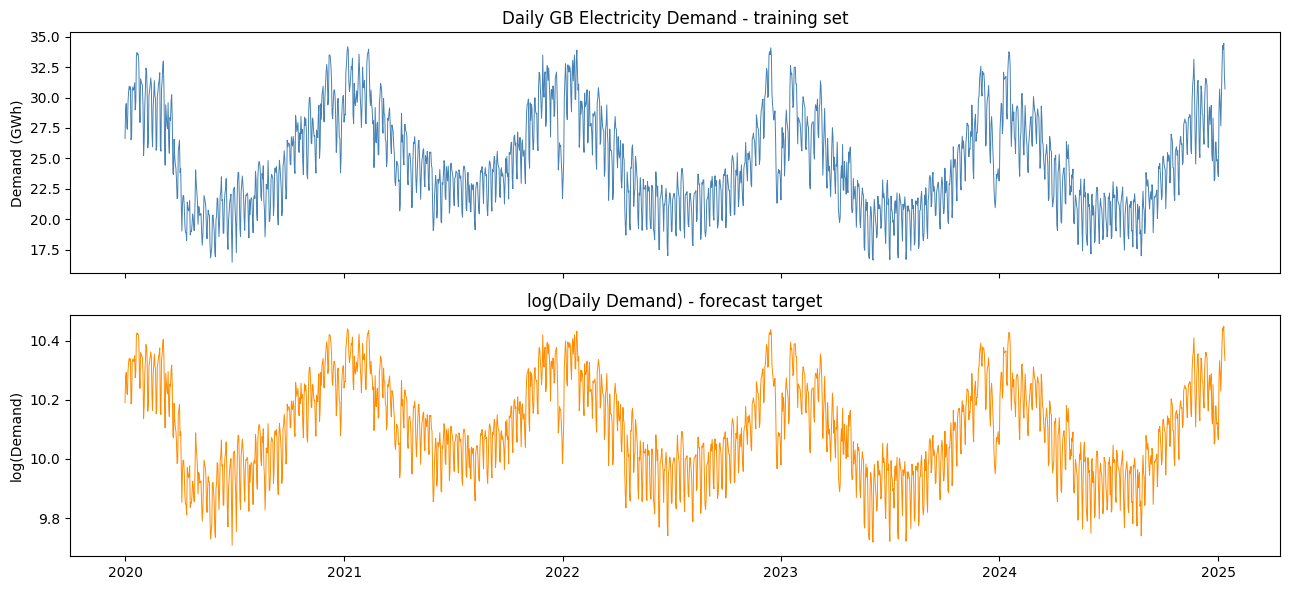

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(df_train.index, df_train["demand_mwh"] / 1000, lw=0.7, color="steelblue")
axes[0].set_ylabel("Demand (GWh)")
axes[0].set_title("Daily GB Electricity Demand - training set")

axes[1].plot(df_train.index, df_train["log_demand"], lw=0.7, color="darkorange")
axes[1].set_ylabel("log(Demand)")
axes[1].set_title("log(Daily Demand) - forecast target")

plt.tight_layout()
plt.show()


### 4.3 Within-year and within-week patterns

/var/folders/xc/gnb56rb95hsf030jccyq499c0000gn/T/ipykernel_89300/3529209212.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x="month", y="log_demand", ax=axes[0],
/var/folders/xc/gnb56rb95hsf030jccyq499c0000gn/T/ipykernel_89300/3529209212.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
/var/folders/xc/gnb56rb95hsf030jccyq499c0000gn/T/ipykernel_89300/3529209212.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x="day_of_week", y="log_demand", ax=axes[1],
/var/folders/xc/gnb56rb95hsf030jccyq499c0000gn/T/ipykernel_893

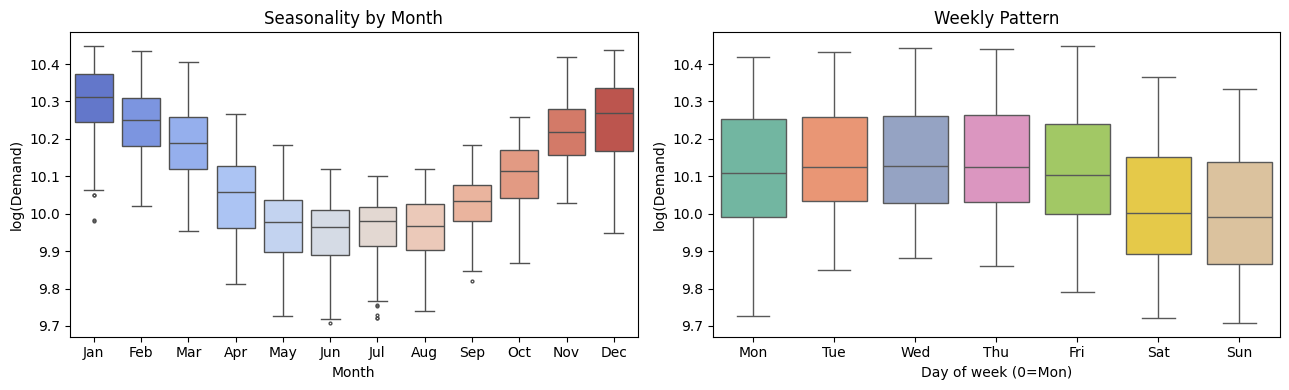

In [10]:
tmp = df_train.copy()
tmp["month"]       = tmp.index.month
tmp["day_of_week"] = tmp.index.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=tmp, x="month", y="log_demand", ax=axes[0],
            palette="coolwarm", flierprops=dict(markersize=2))
axes[0].set_xlabel("Month")
axes[0].set_ylabel("log(Demand)")
axes[0].set_title("Seasonality by Month")
axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])

sns.boxplot(data=tmp, x="day_of_week", y="log_demand", ax=axes[1],
            palette="Set2", flierprops=dict(markersize=2))
axes[1].set_xlabel("Day of week (0=Mon)")
axes[1].set_ylabel("log(Demand)")
axes[1].set_title("Weekly Pattern")
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

plt.tight_layout()
plt.show()


### 4.4 Autocorrelation of log(demand)

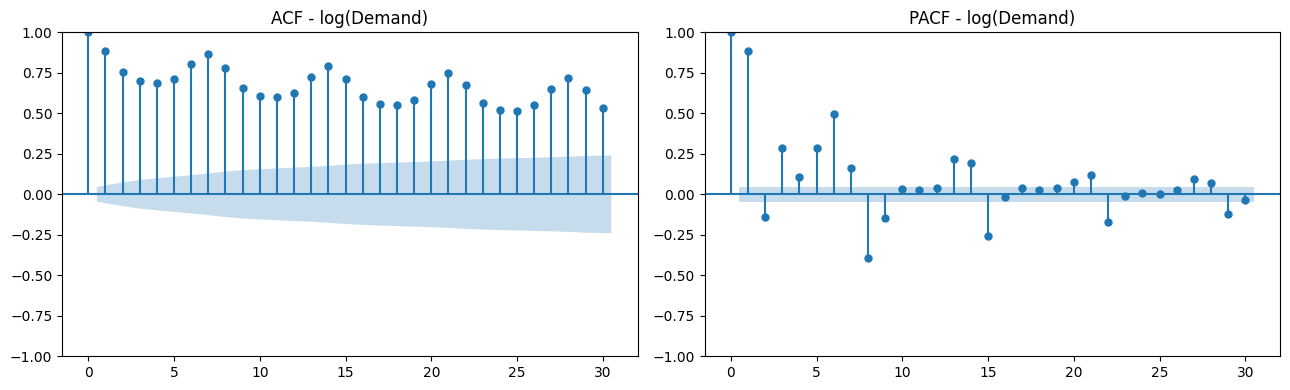

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( df_train["log_demand"].dropna(), lags=30, ax=axes[0], title="ACF - log(Demand)")
plot_pacf(df_train["log_demand"].dropna(), lags=30, ax=axes[1], title="PACF - log(Demand)")
plt.tight_layout()
plt.show()


### 4.5 Temperature and sunshine vs demand

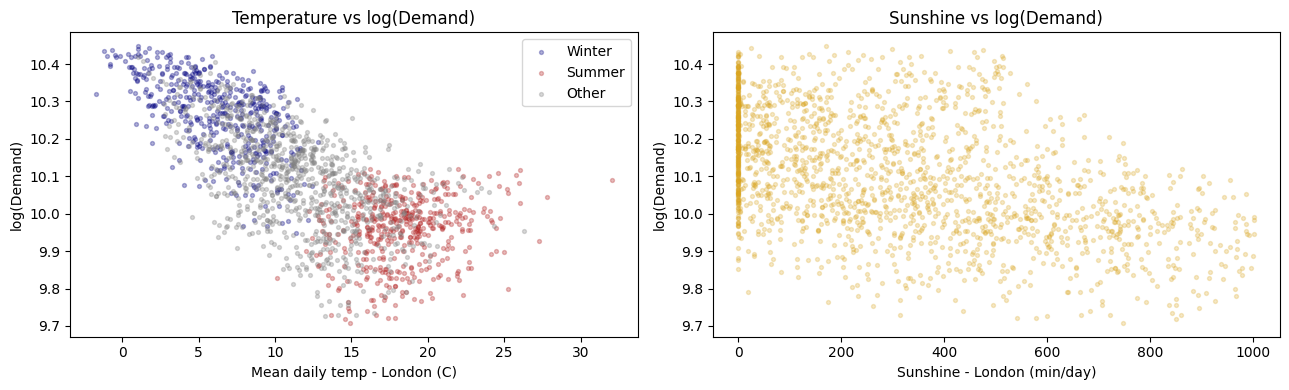

In [12]:
tmp["month"] = tmp.index.month
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for season, months, color in [("Winter",[12,1,2],"navy"),
                               ("Summer",[6,7,8],"firebrick"),
                               ("Other",[3,4,5,9,10,11],"grey")]:
    mask = tmp["month"].isin(months)
    axes[0].scatter(tmp.loc[mask,"temp_london_mean"], tmp.loc[mask,"log_demand"],
                    alpha=0.3, s=8, color=color, label=season)
axes[0].legend()
axes[0].set_xlabel("Mean daily temp - London (C)")
axes[0].set_ylabel("log(Demand)")
axes[0].set_title("Temperature vs log(Demand)")
axes[1].scatter(tmp["sun_london"], tmp["log_demand"], alpha=0.25, s=8, color="goldenrod")
axes[1].set_xlabel("Sunshine - London (min/day)")
axes[1].set_ylabel("log(Demand)")
axes[1].set_title("Sunshine vs log(Demand)")
plt.tight_layout()
plt.show()


## 5. Feature Engineering

Features are computed on the full `df` so that rolling means at the start of the test set can look back into the training period. Every feature at time *t* depends only on data at *t-1* or earlier; no test labels are used.


### 5.1 Build the feature matrix

In [13]:
# ── Easter helper (must be defined first) ────────────────────────────────────
def _easter_date(year):
    """Anonymous Gregorian Easter algorithm — no extra imports needed."""
    a = year % 19; b = year // 100; c = year % 100
    d = b // 4;  e = b % 4;  f = (b + 8) // 25;  g = (b - f + 1) // 3
    h = (19*a + b - d - g + 15) % 30;  i = c // 4;  k = c % 4
    l = (32 + 2*e + 2*i - h - k) % 7;  m = (a + 11*h + 22*l) // 451
    month = (h + l - 7*m + 114) // 31
    day   = ((h + l - 7*m + 114) % 31) + 1
    return pd.Timestamp(year=year, month=month, day=day)

easter_dates   = {yr: _easter_date(yr) for yr in range(2020, 2027)}
uk_hols        = holidays.UnitedKingdom(years=range(2020, 2027))
uk_holiday_set = {pd.Timestamp(d).date() for d in uk_hols.keys()}

# ── Day length helper ─────────────────────────────────────────────────────────
from math import radians, sin, cos, acos

def _day_length_hours(date, lat=52.5):
    doy = date.day_of_year
    dec = radians(23.45 * sin(radians(360 / 365 * (doy - 81))))
    lat_r = radians(lat)
    cos_ha = -sin(dec) * sin(lat_r) / (cos(dec) * cos(lat_r))
    cos_ha = max(-1, min(1, cos_ha))
    return 2 * acos(cos_ha) * 12 / 3.14159

# ── Feature matrix ────────────────────────────────────────────────────────────
features = pd.DataFrame(index=df.index)

# ── Temperature ───────────────────────────────────────────────────────────────
for city in ["london", "leeds", "bristol"]:
    features[f"HDD_{city}"]         = np.maximum(0, 15.5 - df[f"temp_{city}_mean"])
    features[f"CDD_{city}"]         = np.maximum(0, df[f"temp_{city}_mean"] - 22.0)
    features[f"temp_{city}_spread"] = df[f"temp_{city}_max"] - df[f"temp_{city}_min"]

# Lagged HDD (thermal inertia)
for city in ["london", "leeds", "bristol"]:
    features[f"HDD_{city}_lag1"] = features[f"HDD_{city}"].shift(1)

# HDD x weekend interaction (mild weekend suppression)
is_weekend = (df.index.dayofweek >= 5).astype(int)
for city in ["london", "leeds", "bristol"]:
    features[f"HDD_{city}_x_weekend"] = features[f"HDD_{city}"] * is_weekend

# ── Day-of-week dummies (Monday = reference) ──────────────────────────────────
day_names   = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
dow_dummies = pd.get_dummies(df.index.dayofweek, prefix="dow")
dow_dummies.index = df.index
dow_dummies = dow_dummies.rename(
    columns={f"dow_{k}": f"dow_{v}" for k, v in day_names.items()}
)
dow_dummies = dow_dummies.drop(columns=["dow_Mon"]).astype(int)
features = features.join(dow_dummies)

# ── Month dummies (January = reference) ───────────────────────────────────────
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
month_dummies = pd.get_dummies(df.index.month, prefix="month")
month_dummies.index = df.index
month_dummies = month_dummies.rename(
    columns={f"month_{k}": f"month_{v}" for k, v in month_names.items()}
)
month_dummies = month_dummies.drop(columns=["month_Jan"]).astype(int)
features = features.join(month_dummies)

# ── Sunshine ──────────────────────────────────────────────────────────────────
for city in ["london", "leeds", "bristol"]:
    features[f"sun_{city}_h"] = df[f"sun_{city}"] / 60.0

# ── Day length ──────────────────────────────────────
features["day_length_h"] = df.index.map(_day_length_hours)

# Low HDD regime: spring/summer behavioural mode (anchored on London)
features["low_HDD_regime"] = (features["HDD_london"] < 4).astype(int)

# Sunshine x low HDD regime for all cities
for city in ["london", "leeds", "bristol"]:
    features[f"sun_{city}_x_low_HDD"] = (
        features[f"sun_{city}_h"] * features["low_HDD_regime"]
    )

# ── Demand lags and rolling means ─────────────────────────────────────────────
log_d = df["log_demand"]

features["roll7_mean"]    = log_d.shift(2).rolling(7,  min_periods=4).mean()
features["roll28_mean"]   = log_d.shift(2).rolling(28, min_periods=14).mean()

features["lag_2"]         = log_d.shift(2)
features["lag_7"]         = log_d.shift(7)
features["lag_364"]       = log_d.shift(364)
features["lag_365_roll7"] = log_d.shift(365).rolling(7).mean()

# ── Holiday features ──────────────────────────────────────────────────────────

# Granular Easter dummies
def _get_easter_day_type(date, easter_dates):
    d = date.date()
    easter = easter_dates.get(date.year)
    if easter is None:
        return "none"
    diff = (pd.Timestamp(d) - easter).days
    mapping = {
        -2: "easter_good_friday",
        -1: "easter_saturday",
         0: "easter_sunday",
         1: "easter_monday"
    }
    return mapping.get(diff, "none")

easter_day_types = df.index.map(lambda d: _get_easter_day_type(d, easter_dates))
for etype in ["easter_good_friday", "easter_saturday",
              "easter_sunday", "easter_monday"]:
    features[f"is_{etype}"] = (easter_day_types == etype).astype(int)

# Day after Easter Monday
features["is_easter_tuesday"] = df.index.map(
    lambda d: int(
        (pd.Timestamp(d.date()) - easter_dates[d.year]).days == 2
    )
)

# Non-Easter holiday types
def _get_holiday_type(date, easter_dates, uk_holiday_set):
    d = date.date()
    easter = easter_dates.get(date.year)
    days_from_easter = (pd.Timestamp(d) - easter).days if easter else None

    if days_from_easter is not None and days_from_easter in {-2, -1, 0, 1}:
        return "none"  # handled by granular Easter dummies
    if d.month == 12 and d.day in range(24, 28):
        return "christmas"
    if (d.month == 12 and d.day == 31) or (d.month == 1 and d.day == 1):
        return "new_year"
    if d in uk_holiday_set:
        return "generic_bh"
    return "none"

holiday_types = df.index.map(
    lambda d: _get_holiday_type(d, easter_dates, uk_holiday_set)
)
for htype in ["christmas", "new_year", "generic_bh"]:
    features[f"is_holiday_{htype}"] = (holiday_types == htype).astype(int)

# Day before / after bank holiday
features["day_before_holiday"] = df.index.map(
    lambda d: int((d + pd.Timedelta(days=1)).date() in uk_holiday_set)
)
features["day_after_holiday"] = df.index.map(
    lambda d: int((d - pd.Timedelta(days=1)).date() in uk_holiday_set)
)

# ── School holidays ───────────────────────────────────────────────────────────
_school_hols = set()
for _yr in range(2020, 2027):
    _e = _easter_date(_yr)
    for _off in range(-7, 8):
        if _off not in {-2, -1, 0, 1}:          # exclude Easter core
            _school_hols.add((_e + pd.Timedelta(days=_off)).date())
    for _d in pd.date_range(f"{_yr}-07-20", f"{_yr}-09-06"):   # Summer
        _school_hols.add(_d.date())
    for _d in pd.date_range(f"{_yr}-12-22", f"{_yr+1}-01-04"): # Christmas
        _school_hols.add(_d.date())
    for _d in pd.date_range(f"{_yr}-02-15", f"{_yr}-02-22"):   # Feb half-term
        _school_hols.add(_d.date())
    for _d in pd.date_range(f"{_yr}-05-25", f"{_yr}-05-31"):   # May half-term
        _school_hols.add(_d.date())
    for _d in pd.date_range(f"{_yr}-10-25", f"{_yr}-11-01"):   # Oct half-term
        _school_hols.add(_d.date())

features["is_school_holiday"] = df.index.map(
    lambda d: int(d.date() in _school_hols)
)

# ── Trend, structural and COVID ───────────────────────────────────────────────
features["year_trend"] = (
    (df.index - pd.Timestamp("2020-01-01")).days / 365.25
)


features["is_covid"] = (
    (df.index >= pd.Timestamp("2020-03-23")) &
    (df.index <= pd.Timestamp("2021-07-19"))
).astype(int)

# ___ Anomaly feature _________________________________________________________
# Historical mean and std of temperature by day of year
doy_stats = (df.groupby(df.index.dayofyear)["temp_london_mean"]
               .agg(["mean", "std"])
               .rename(columns={"mean": "temp_doy_mean", 
                                 "std": "temp_doy_std"}))

df["temp_doy_mean"] = df.index.dayofyear.map(doy_stats["temp_doy_mean"])
df["temp_doy_std"]  = df.index.dayofyear.map(doy_stats["temp_doy_std"])

# How many standard deviations above normal is today's temperature
features["temp_anomaly"] = (
    (df["temp_london_mean"] - df["temp_doy_mean"]) / 
    df["temp_doy_std"]
)

# ── Target ────────────────────────────────────────────────────────────────────
features["log_demand"] = df["log_demand"]

print(f"Full feature matrix: {features.shape}")
print(f"Columns ({len(features.columns)}): {list(features.columns)}")

Full feature matrix: (2334, 61)
Columns (61): ['HDD_london', 'CDD_london', 'temp_london_spread', 'HDD_leeds', 'CDD_leeds', 'temp_leeds_spread', 'HDD_bristol', 'CDD_bristol', 'temp_bristol_spread', 'HDD_london_lag1', 'HDD_leeds_lag1', 'HDD_bristol_lag1', 'HDD_london_x_weekend', 'HDD_leeds_x_weekend', 'HDD_bristol_x_weekend', 'dow_Tue', 'dow_Wed', 'dow_Thu', 'dow_Fri', 'dow_Sat', 'dow_Sun', 'month_Feb', 'month_Mar', 'month_Apr', 'month_May', 'month_Jun', 'month_Jul', 'month_Aug', 'month_Sep', 'month_Oct', 'month_Nov', 'month_Dec', 'sun_london_h', 'sun_leeds_h', 'sun_bristol_h', 'day_length_h', 'low_HDD_regime', 'sun_london_x_low_HDD', 'sun_leeds_x_low_HDD', 'sun_bristol_x_low_HDD', 'roll7_mean', 'roll28_mean', 'lag_2', 'lag_7', 'lag_364', 'lag_365_roll7', 'is_easter_good_friday', 'is_easter_saturday', 'is_easter_sunday', 'is_easter_monday', 'is_easter_tuesday', 'is_holiday_christmas', 'is_holiday_new_year', 'is_holiday_generic_bh', 'day_before_holiday', 'day_after_holiday', 'is_school_ho

### 5.2 Train / test split of the feature matrix

In [14]:
FEATURE_COLS = [c for c in features.columns if c != "log_demand"]

TRAIN_END = str(pd.to_datetime(TEST_START) - pd.Timedelta(days=1))
features_train = features.loc[:TRAIN_END].copy()
features_test  = features.loc[TEST_START:].copy()

train_clean = features_train.dropna()
test_clean  = features_test.dropna()

print(f"features_train (clean): {train_clean.shape}")
print(f"features_test  (clean): {test_clean.shape}")


features_train (clean): (1830, 61)
features_test  (clean): (130, 61)


### 5.3 Correlation with log(demand) -- training set

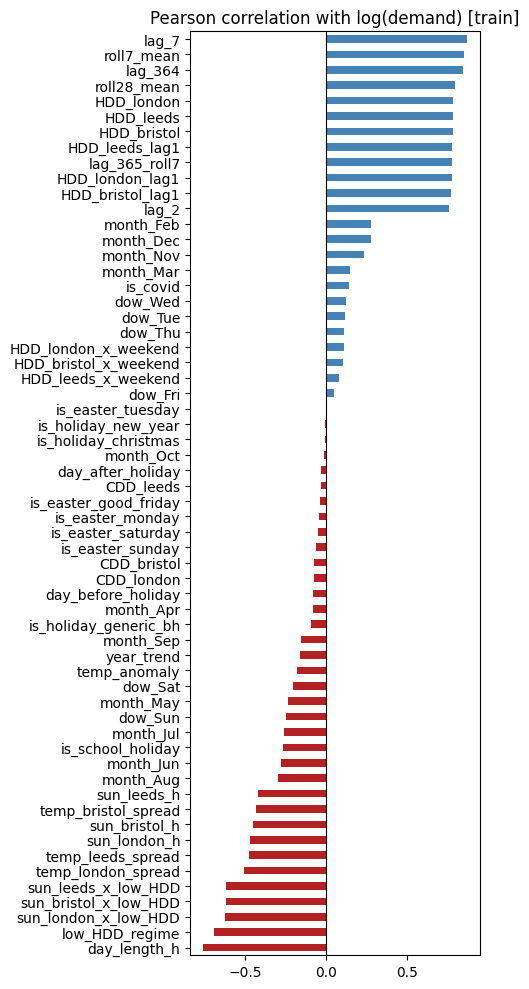

In [15]:
correlations = (
    train_clean.corr()["log_demand"]
    .drop("log_demand")
    .sort_values()
)
fig, ax = plt.subplots(figsize=(5, 10))
colors = ["firebrick" if v < 0 else "steelblue" for v in correlations]
correlations.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Pearson correlation with log(demand) [train]")
plt.tight_layout()
plt.show()


## 6. OLS Model -- Training Set Fit

In [16]:
X_train_sm = sm.add_constant(train_clean[FEATURE_COLS])
y_train_sm = train_clean["log_demand"]

model = sm.OLS(y_train_sm, X_train_sm).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             log_demand   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     587.2
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        21:04:33   Log-Likelihood:                 3562.0
No. Observations:                1830   AIC:                            -7002.
Df Residuals:                    1769   BIC:                            -6666.
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     3.38

In [17]:
y_pred_train = model.predict(X_train_sm)
resid_train  = y_train_sm - y_pred_train

rmse_tr = np.sqrt(mean_squared_error(y_train_sm, y_pred_train))
mae_tr  = mean_absolute_error(y_train_sm, y_pred_train)
print(f"In-sample R^2  : {model.rsquared:.4f}")
print(f"In-sample RMSE : {rmse_tr:.4f} log units  (~{(np.exp(rmse_tr)-1)*100:.2f}%)")
print(f"In-sample MAE  : {mae_tr:.4f} log units  (~{(np.exp(mae_tr)-1)*100:.2f}%)")


In-sample R^2  : 0.9522
In-sample RMSE : 0.0345 log units  (~3.52%)
In-sample MAE  : 0.0272 log units  (~2.75%)


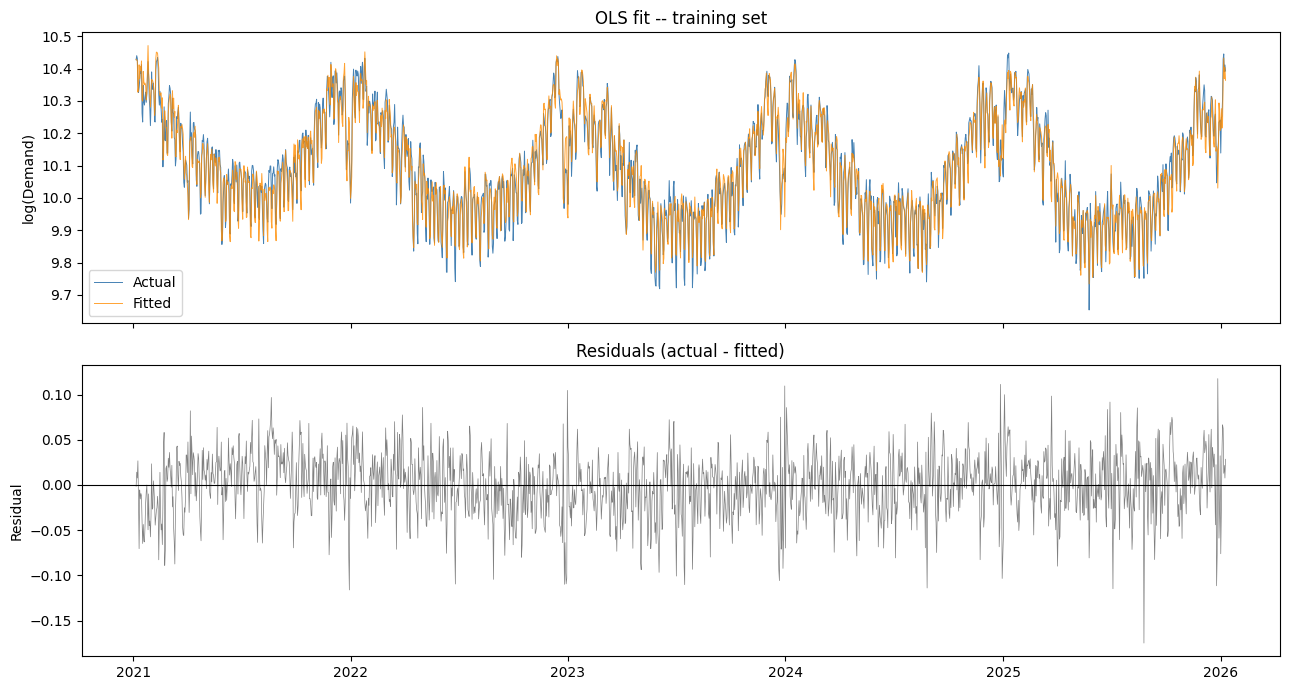

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(y_train_sm.index, y_train_sm.values, lw=0.7, color="steelblue", label="Actual")
axes[0].plot(y_train_sm.index, y_pred_train.values, lw=0.7, color="darkorange", alpha=0.8, label="Fitted")
axes[0].set_ylabel("log(Demand)")
axes[0].set_title("OLS fit -- training set")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].plot(y_train_sm.index, resid_train.values, lw=0.5, color="grey")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals (actual - fitted)")
plt.tight_layout()
plt.show()


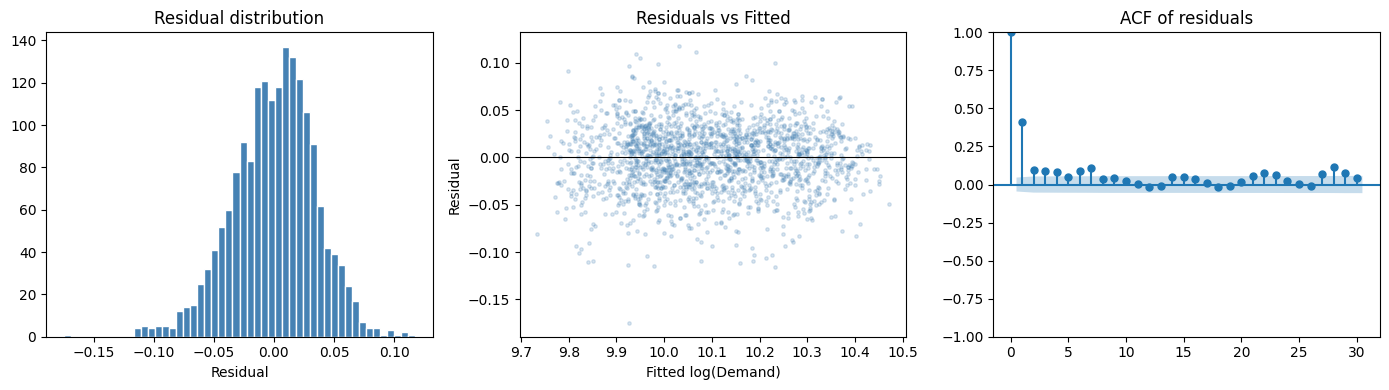

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(resid_train, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Residual")
axes[0].set_title("Residual distribution")
axes[1].scatter(y_pred_train, resid_train, alpha=0.2, s=6, color="steelblue")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Fitted log(Demand)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted")
plot_acf(resid_train, lags=30, ax=axes[2], title="ACF of residuals")
plt.tight_layout()
plt.show()


## 7. Probabilistic Test Forecast -- Expanding Window

We assume:
$$\log(\text{demand}_t) \mid \mathbf{x}_t \sim \mathcal{N}(\mu_t,\, \sigma_t^2)$$

For each test day *t* we:
1. Expand the training window to include all observations before *t*.
2. Refit OLS and compute the **OLS predictive distribution**:
   - $\mu_t = \mathbf{x}_t^\top \hat{\boldsymbol{\beta}}$
   - $\sigma_t^2 = \widehat{\text{MSE}} \cdot \bigl(1 + \mathbf{x}_t^\top (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{x}_t\bigr)$

   The $(1 + \cdots)$ term accounts for both irreducible noise and parameter uncertainty. For $n \gg p$ the correction is negligible but we include it for correctness.

3. Score each forecast with the **log score** (logarithmic scoring rule):
$$S_t = \log p(y_t \mid \mu_t, \sigma_t) = -\tfrac{1}{2}\log(2\pi) - \log \sigma_t - \tfrac{1}{2}\left(\frac{y_t - \mu_t}{\sigma_t}\right)^2$$
Higher is better. Averaging over all test days gives the **Mean Log Score (MLS)**.


### 7.1 Expanding-window probabilistic forecast loop

In [20]:
import time

mus    = {}
sigmas = {}
t0 = time.time()

for i, date in enumerate(test_clean.index):

    # Expanding training window
    tw = features.loc[: date - pd.Timedelta(days=1)].dropna()
    X_tr = tw[FEATURE_COLS].values
    y_tr = tw["log_demand"].values
    n, p = X_tr.shape

    # OLS
    X_c     = np.column_stack([np.ones(n), X_tr])
    p1      = p + 1
    XtX     = X_c.T @ X_c
    XtX_inv = np.linalg.inv(XtX)
    beta    = XtX_inv @ (X_c.T @ y_tr)
    resid_tr = y_tr - X_c @ beta
    mse      = np.dot(resid_tr, resid_tr) / (n - p1)

    # XGBoost on OLS residuals (2-year sliding window)
    xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_mask = tw.index >= (date - pd.Timedelta(days=1095))
    xgb.fit(X_tr[xgb_mask], resid_tr[xgb_mask])

    # AR(1,7) on XGB-corrected residuals (last 90 days)
    _ar_idx   = tw.index >= (tw.index.max() - pd.Timedelta(days=90))
    _ar_vals      = resid_tr[_ar_idx] - xgb.predict(X_tr[_ar_idx])
    _ar_fit       = AutoReg(_ar_vals, lags=[2, 7], old_names=False).fit()
    ar_correction = float(np.asarray(_ar_fit.forecast(1))[-1])

    # Test point
    x_test = test_clean.loc[date, FEATURE_COLS].values
    x_star = np.r_[1.0, x_test]
    mu_ols         = x_star @ beta
    xgb_correction = xgb.predict(x_test.reshape(1, -1))[0]
    mu_t           = mu_ols + xgb_correction + ar_correction

    var_t   = mse * (1.0 + x_star @ XtX_inv @ x_star)
    sigma_t = np.sqrt(var_t)

    mus[date]    = mu_t
    sigmas[date] = sigma_t


mu_series    = pd.Series(mus,    name="mu")
sigma_series = pd.Series(sigmas, name="sigma")
y_actual     = test_clean["log_demand"]

print(f"Done in {time.time()-t0:.1f}s")
print(f"Mean predicted sigma : {sigma_series.mean():.4f}")
print(f"Sigma range          : [{sigma_series.min():.4f}, {sigma_series.max():.4f}]")

Done in 39.7s
Mean predicted sigma : 0.0358
Sigma range          : [0.0354, 0.0392]


### 7.2 Log score per day and summary metrics

In [21]:
# Log score for our expanding-window model
log_scores_ew = pd.Series(
    stats.norm.logpdf(y_actual.values, loc=mu_series.values, scale=sigma_series.values),
    index=y_actual.index,
    name="log_score_ew"
)

# --- Baseline: climatological forecast ---
# Normal distribution fit to training log-demand; ignores all features
mu_clim    = train_clean["log_demand"].mean()
sigma_clim = train_clean["log_demand"].std()
log_scores_clim = pd.Series(
    stats.norm.logpdf(y_actual.values, loc=mu_clim, scale=sigma_clim),
    index=y_actual.index,
    name="log_score_clim"
)

print(f"Climatological baseline  :  mu={mu_clim:.4f}, sigma={sigma_clim:.4f}")
print()

summary = pd.DataFrame({
    "Mean Log Score"  : [log_scores_ew.mean(),   log_scores_clim.mean()],
    "Median Log Score": [log_scores_ew.median(),  log_scores_clim.median()],
    "Std Log Score"   : [log_scores_ew.std(),     log_scores_clim.std()],
}, index=["Expanding-window OLS", "Climatological baseline"])
print(summary.round(4))
print()

# Point-forecast metrics alongside
rmse = np.sqrt(mean_squared_error(y_actual, mu_series))
mae  = mean_absolute_error(y_actual, mu_series)
ss_res = np.sum((y_actual - mu_series)**2)
ss_tot = np.sum((y_actual - y_actual.mean())**2)
r2_oos = 1 - ss_res / ss_tot
print(f"Point-forecast metrics (mean as prediction):")
print(f"  OOS R^2 : {r2_oos:.4f}")
print(f"  RMSE    : {rmse:.4f} log units  (~{(np.exp(rmse)-1)*100:.2f}%)")
print(f"  MAE     : {mae:.4f} log units  (~{(np.exp(mae)-1)*100:.2f}%)")


Climatological baseline  :  mu=10.0932, sigma=0.1580

                         Mean Log Score  Median Log Score  Std Log Score
Expanding-window OLS             1.9520            2.2219         0.6281
Climatological baseline          0.4135            0.5985         0.4795

Point-forecast metrics (mean as prediction):
  OOS R^2 : 0.9514
  RMSE    : 0.0344 log units  (~3.50%)
  MAE     : 0.0270 log units  (~2.74%)


### 7.3 Predictive distribution fan chart

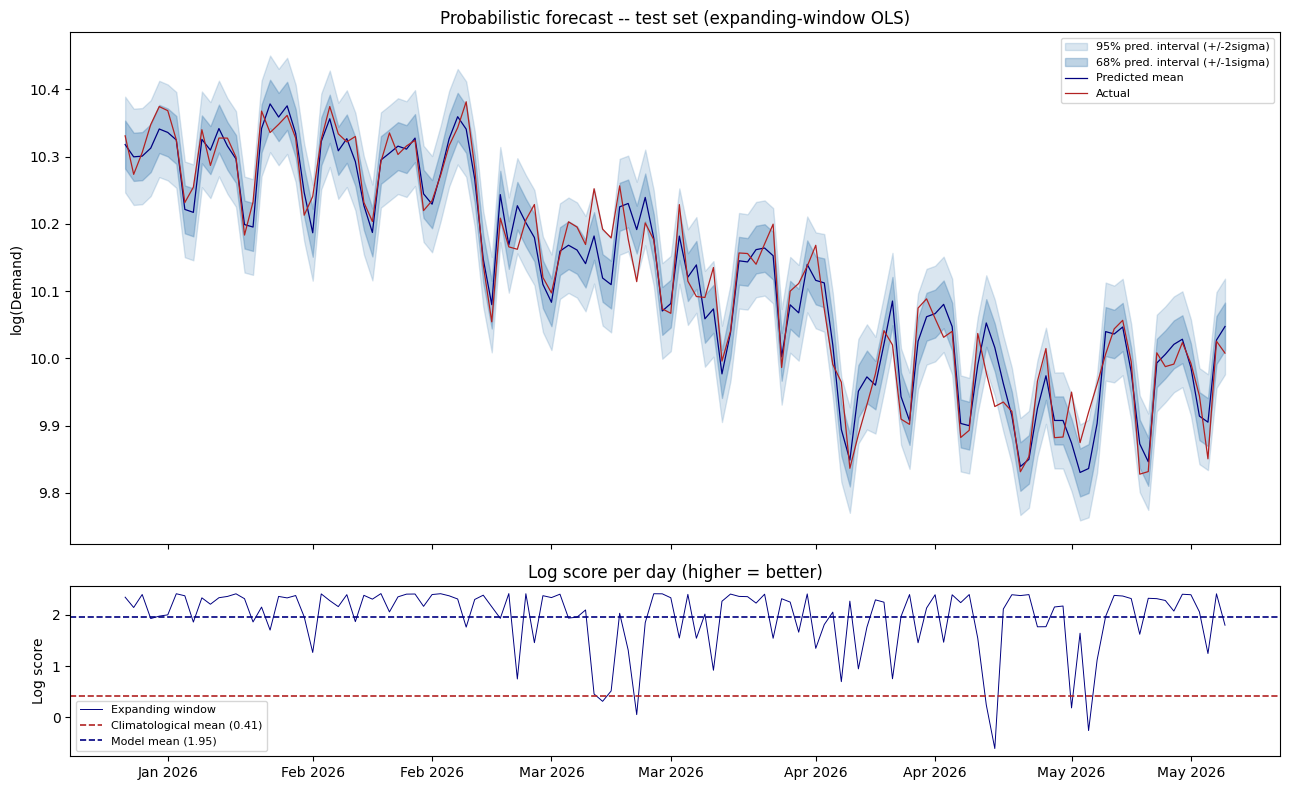

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.fill_between(mu_series.index,
                mu_series - 2*sigma_series, mu_series + 2*sigma_series,
                alpha=0.20, color="steelblue", label="95% pred. interval (+/-2sigma)")

ax.fill_between(mu_series.index,
                mu_series - sigma_series, mu_series + sigma_series,
                alpha=0.35, color="steelblue", label="68% pred. interval (+/-1sigma)")

ax.plot(mu_series.index, mu_series.values, lw=0.9, color="navy", label="Predicted mean")
ax.plot(y_actual.index, y_actual.values, lw=0.9, color="firebrick", label="Actual", zorder=3)
ax.set_ylabel("log(Demand)")
ax.set_title("Probabilistic forecast -- test set (expanding-window OLS)")
ax.legend(loc="upper right", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

axes[1].plot(log_scores_ew.index, log_scores_ew.values, lw=0.7, color="navy",
             label="Expanding window")
axes[1].axhline(log_scores_clim.mean(), color="firebrick", lw=1.2, linestyle="--",
                label=f"Climatological mean ({log_scores_clim.mean():.2f})")
axes[1].axhline(log_scores_ew.mean(), color="navy", lw=1.2, linestyle="--",
                label=f"Model mean ({log_scores_ew.mean():.2f})")
axes[1].set_ylabel("Log score")
axes[1].set_title("Log score per day (higher = better)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 8. 2026 Forecast Using Weather Model Temperature Forecasts

This section evaluates the model in the realistic competition setting:

- **Training set**: 2020-01-01 to 2025-12-31 (6 full years).
- **Test set**: 2026-01-10 to 2026-04-26 (**107 days**).
  The first 9 days of January 2026 have no forecast temperature data available
  (forecast series starts 2026-01-10), so the test window begins there.
- **Temperature features** for the test set are built from the **weather model forecasts**
  stored in columns 4-6 of the Temperature sheet ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â these are rounded 6-hourly model
  output values, distinct from the precise observed values in columns 1-3.

Section 7 used actual observed temperatures for both 2025 and 2026 (the "perfect weather"
upper bound). Here we replace only the test-period temperature-derived features (HDD, CDD,
diurnal spread) with forecast-based equivalents.  All other features (rolling means, sunshine,
calendar dummies, holidays) are unchanged.


### 8.1 Load and aggregate weather forecast temperatures

In [23]:
# Columns 4-6 of the Temperature sheet contain 6-hourly weather model forecasts.
# The header rows ("Forecasts", city names) are dropped by pd.to_numeric coercion.
raw_fc = pd.read_excel(DATA_PATH, sheet_name="Temperature", header=None,
                       usecols=[0, 4, 5, 6])
raw_fc.columns = ["datetime", "fc_london", "fc_leeds", "fc_bristol"]
raw_fc["datetime"] = pd.to_datetime(raw_fc["datetime"], errors="coerce")
raw_fc = raw_fc.dropna(subset=["datetime"])
for col in ["fc_london", "fc_leeds", "fc_bristol"]:
    raw_fc[col] = pd.to_numeric(raw_fc[col], errors="coerce")
raw_fc = raw_fc.dropna().set_index("datetime").sort_index()

# Aggregate 6-hourly forecasts to daily mean / min / max
fc_daily = raw_fc.resample("D").agg(
    fc_london_mean  =("fc_london",  "mean"),
    fc_london_min   =("fc_london",  "min"),
    fc_london_max   =("fc_london",  "max"),
    fc_leeds_mean   =("fc_leeds",   "mean"),
    fc_leeds_min    =("fc_leeds",   "min"),
    fc_leeds_max    =("fc_leeds",   "max"),
    fc_bristol_mean =("fc_bristol", "mean"),
    fc_bristol_min  =("fc_bristol", "min"),
    fc_bristol_max  =("fc_bristol", "max"),
)

TEST8_START = "2026-01-10"   # first day with complete forecast temperature data
TEST8_END   = "2026-07-03"
# TRAIN8_END  = "2025-12-31"

VAL8_START  = "2025-01-13"
VAL8_END    = "2025-03-20"


fc_test = fc_daily.loc[TEST8_START:TEST8_END]
print(f"Forecast temp series : {raw_fc.index.min().date()} -> {raw_fc.index.max().date()}")
print(f"Test window          : {fc_test.index.min().date()} -> {fc_test.index.max().date()}  ({len(fc_test)} days)")
print(f"Missing daily values : {fc_test.isna().sum().sum()}")
fc_test.head()

fc_val = fc_daily.loc[VAL8_START:VAL8_END]
print(f"Validation window    : {fc_val.index.min().date()} -> {fc_val.index.max().date()}  ({len(fc_val)} days)")
print(f"Missing daily values : {fc_val.isna().sum().sum()}")


Forecast temp series : 2025-01-13 -> 2026-05-22
Test window          : 2026-01-10 -> 2026-05-22  (133 days)
Missing daily values : 0
Validation window    : 2025-01-13 -> 2025-03-20  (67 days)
Missing daily values : 0


### 8.2 Forecast vs actual temperature (sanity check)

Forecast vs actual -- London daily mean temp (67 days):
  Mean error (bias) : 0.350 C
  RMSE              : 0.881 C
  MAE               : 0.744 C


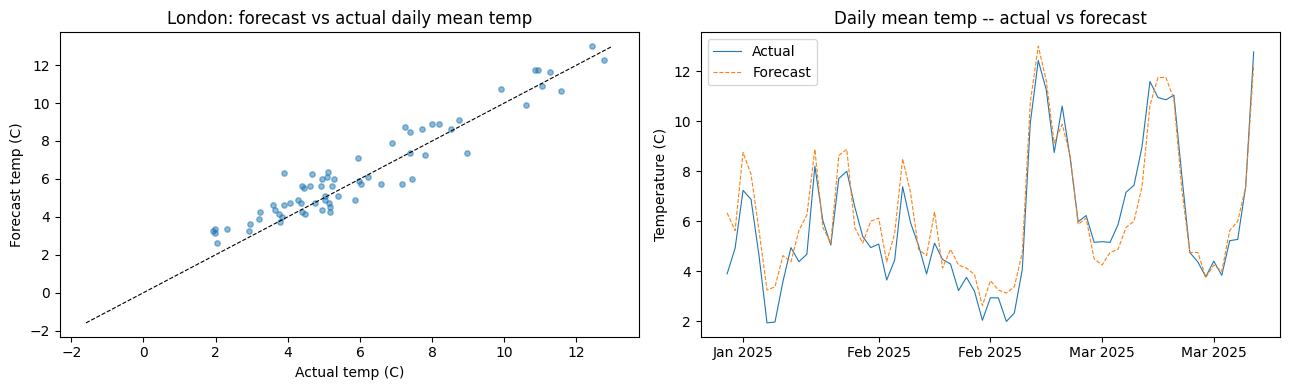

In [24]:
# Actual daily mean temperatures for the same window (from df, already computed)
actual_validation = df.loc[VAL8_START:VAL8_END,
                     ["temp_london_mean","temp_leeds_mean","temp_bristol_mean"]]

comp = pd.DataFrame({
    "actual_london"  : actual_validation["temp_london_mean"],
    "forecast_london": fc_val["fc_london_mean"],
}).dropna()
comp["error"] = comp["forecast_london"] - comp["actual_london"]

print(f"Forecast vs actual -- London daily mean temp ({len(comp)} days):")
print(f"  Mean error (bias) : {comp['error'].mean():.3f} C")
print(f"  RMSE              : {np.sqrt((comp['error']**2).mean()):.3f} C")
print(f"  MAE               : {comp['error'].abs().mean():.3f} C")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(comp["actual_london"], comp["forecast_london"], alpha=0.5, s=15)
lims = [comp.min().min(), comp.max().max()]
axes[0].plot(lims, lims, "k--", lw=0.8)
axes[0].set_xlabel("Actual temp (C)")
axes[0].set_ylabel("Forecast temp (C)")
axes[0].set_title("London: forecast vs actual daily mean temp")

axes[1].plot(comp.index, comp["actual_london"],   lw=0.8, label="Actual")
axes[1].plot(comp.index, comp["forecast_london"], lw=0.8, linestyle="--", label="Forecast")
axes[1].set_ylabel("Temperature (C)")
axes[1].set_title("Daily mean temp -- actual vs forecast")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()


### 8.3 Build test feature set using forecast temperatures

We start from the pre-built `features` matrix (which already has the correct rolling means,
calendar dummies, sunshine, and holiday flags for the test period), then **overwrite only the
temperature-derived columns** (HDD, CDD, diurnal spread) with versions computed from the
forecast temperatures.


In [25]:
# Base: copy the pre-built features for the test window
features_val8  = features.loc[VAL8_START:VAL8_END].copy()
features_test8 = features.loc[TEST8_START:TEST8_END].copy()

def _apply_fc_temp_overrides(feat_df, fc_df):
    """Replace current-day temperature-derived features with forecast-temperature versions.
    Uses index-aligned reindex() to avoid positional misalignment if fc_df has gaps.
    HDD_lag1 is intentionally NOT overridden: T-1 is always a past observed day.
    """
    for city in ["london", "leeds", "bristol"]:
        fc_mean = fc_df[f"fc_{city}_mean"].reindex(feat_df.index)
        fc_min  = fc_df[f"fc_{city}_min" ].reindex(feat_df.index)
        fc_max  = fc_df[f"fc_{city}_max" ].reindex(feat_df.index)
        hdd = np.maximum(0, 15.5 - fc_mean)   # pandas Series, index-aligned
        cdd = np.maximum(0, fc_mean - 22.0)
        feat_df[f"HDD_{city}"]           = hdd
        feat_df[f"CDD_{city}"]           = cdd
        feat_df[f"temp_{city}_spread"]   = fc_max - fc_min
        # HDD_lag1: NOT overridden — previous day's actual HDD is observed at forecast time
        is_wknd = pd.Series((feat_df.index.dayofweek >= 5).astype(int), index=feat_df.index)
        feat_df[f"HDD_{city}_x_weekend"] = hdd * is_wknd

    # Low-HDD regime (spring/summer mode) and sunshine interaction
    hdd_lon = feat_df["HDD_london"]
    feat_df["low_HDD_regime"] = (hdd_lon < 4).astype(int)
    for city in ["london", "leeds", "bristol"]:
        feat_df[f"sun_{city}_x_low_HDD"] = feat_df[f"sun_{city}_h"] * feat_df["low_HDD_regime"]

    # Temperature anomaly: use forecast temp against pre-computed doy stats
    fc_london = fc_df["fc_london_mean"].reindex(feat_df.index)
    doy_mean  = df.loc[feat_df.index, "temp_doy_mean"]
    doy_std   = df.loc[feat_df.index, "temp_doy_std"]
    feat_df["temp_anomaly"] = (fc_london - doy_mean) / doy_std
    return feat_df

features_val8  = _apply_fc_temp_overrides(features_val8,  fc_val)
features_test8 = _apply_fc_temp_overrides(features_test8, fc_test)

features_test8 = features_test8.dropna()
features_val8  = features_val8.dropna()

print(f"Validation : {features_val8.index.min().date()} -> {features_val8.index.max().date()}  ({len(features_val8)} days)")
print(f"Test       : {features_test8.index.min().date()} -> {features_test8.index.max().date()}  ({len(features_test8)} days)")
print(f"Any NaN in test features: {features_test8[FEATURE_COLS].isna().any().any()}")

Validation : 2025-01-13 -> 2025-03-20  (67 days)
Test       : 2026-01-10 -> 2026-05-19  (130 days)
Any NaN in test features: False


### 8.4 Expanding-window probabilistic forecast

Optimal Multiplier found: 0.783


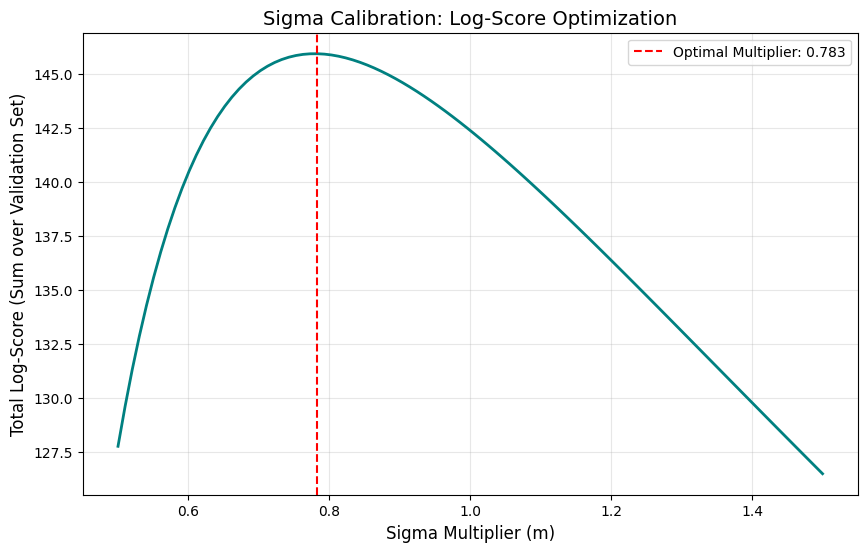

Done in 20.7s  |  Mean sigma: 0.0352


In [38]:
import time

mus8, sigmas8 = {}, {}
t0 = time.time()

validation_results = []

for i, date in enumerate(features_val8.index):
    tw   = features.loc[: date - pd.Timedelta(days=1)].dropna()
    X_tr = tw[FEATURE_COLS].values
    y_tr = tw["log_demand"].values
    n, p = X_tr.shape

    X_c     = np.column_stack([np.ones(n), X_tr])
    XtX_inv = np.linalg.inv(X_c.T @ X_c)
    beta    = XtX_inv @ (X_c.T @ y_tr)
    resid_tr = y_tr - X_c @ beta
    mse      = np.dot(resid_tr, resid_tr) / (n - p - 1)

    # XGBoost on OLS residuals (2-year sliding window)
    xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_mask = tw.index >= (date - pd.Timedelta(days=1095))
    xgb.fit(X_tr[xgb_mask], resid_tr[xgb_mask])

    # AR(1,7) on XGB-corrected residuals (last 90 days)
    _ar_idx   = tw.index >= (tw.index.max() - pd.Timedelta(days=90))
    _ar_vals      = resid_tr[_ar_idx] - xgb.predict(X_tr[_ar_idx])
    _ar_fit       = AutoReg(_ar_vals, lags=[2, 7], old_names=False).fit()
    ar_correction = float(np.asarray(_ar_fit.forecast(1))[-1])

    x_test  = features_val8.loc[date, FEATURE_COLS].values
    x_star  = np.r_[1.0, x_test]
    mu_ols  = x_star @ beta
    xgb_correction = xgb.predict(x_test.reshape(1, -1))[0]

    mus8[date]    = mu_ols + xgb_correction + ar_correction
    sigmas8[date] = np.sqrt(mse * (1.0 + x_star @ XtX_inv @ x_star))

    actual_on_target_date = features.loc[date, "log_demand"]
    if pd.notna(actual_on_target_date):
        validation_results.append((mus8[date], sigmas8[date], actual_on_target_date))


multipliers = np.linspace(0.5, 1.5, 100)
total_scores = []

for m in multipliers:
    score = sum([stats.norm.logpdf(actual, loc=mu, scale=sig * m) for mu, sig, actual in validation_results])
    total_scores.append(score)

best_m = multipliers[np.argmax(total_scores)]
print(f"Optimal Multiplier found: {best_m:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(multipliers, total_scores, color='teal', linewidth=2)
plt.axvline(best_m, color='red', linestyle='--', label=f'Optimal Multiplier: {best_m:.3f}')
plt.title("Sigma Calibration: Log-Score Optimization", fontsize=14)
plt.xlabel("Sigma Multiplier (m)", fontsize=12)
plt.ylabel("Total Log-Score (Sum over Validation Set)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

mu8    = pd.Series(mus8,    name="mu8")
sigma8 = pd.Series(sigmas8, name="sigma8")
y_act8_val = features_val8["log_demand"]

print(f"Done in {time.time()-t0:.1f}s  |  Mean sigma: {sigma8.mean():.4f}")

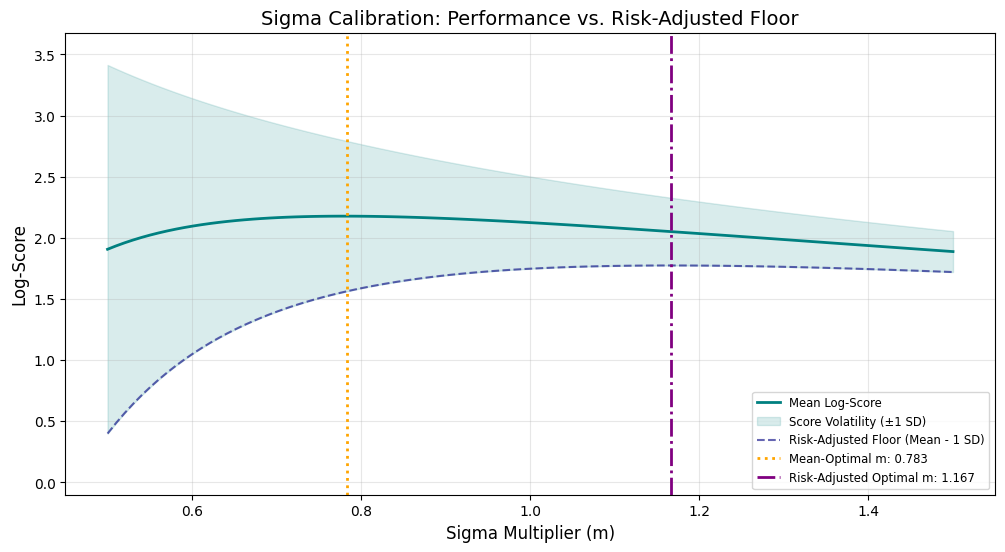

In [40]:
score_means = []
score_stds = []

for m in multipliers:
    daily_scores = [stats.norm.logpdf(actual, loc=mu, scale=sig * m) for mu, sig, actual in validation_results]
    score_means.append(np.mean(daily_scores))
    score_stds.append(np.std(daily_scores))

plt.figure(figsize=(12, 6))

# Convert to numpy arrays for easier math
means = np.array(score_means)
stds = np.array(score_stds)

# --- NEW: Calculate the Lower Bound (The Floor) ---
lower_bound = means - stds
best_m_conservative = multipliers[np.argmax(lower_bound)]

# 1. Plot the Mean Log-Score
plt.plot(multipliers, means, color='teal', linewidth=2, label='Mean Log-Score')

# 2. Add the Stability Ribbon (Mean +/- 1 Standard Deviation)
plt.fill_between(multipliers, means - stds, means + stds, 
                 color='teal', alpha=0.15, label='Score Volatility (±1 SD)')

# 3. Plot the Lower Bound Line specifically
plt.plot(multipliers, lower_bound, color='navy', linestyle='--', alpha=0.6, label='Risk-Adjusted Floor (Mean - 1 SD)')

# 4. Highlight the different Optimal points
# Sum/Mean Optimal (The Peak)
plt.axvline(best_m, color='orange', linestyle=':', linewidth=2,
            label=f'Mean-Optimal m: {best_m:.3f}')

# Risk-Adjusted Optimal (The highest Floor)
plt.axvline(best_m_conservative, color='purple', linestyle='-.', linewidth=2,
            label=f'Risk-Adjusted Optimal m: {best_m_conservative:.3f}')

# Formatting
plt.title("Sigma Calibration: Performance vs. Risk-Adjusted Floor", fontsize=14)
plt.xlabel("Sigma Multiplier (m)", fontsize=12)
plt.ylabel("Log-Score", fontsize=12)
plt.legend(loc='lower right', fontsize='small')
plt.grid(True, alpha=0.3)

# Focus the Y-axis (Reference image_65f900.png shows the range)
plt.ylim(lower_bound.min() - 0.5, means.max() + 1.5) 

plt.savefig('images/sigma_calibration.png', dpi=300)
plt.show()


In [28]:
import time

y_act8 = features_test8["log_demand"]
mus8_test, sigmas8_test = {}, {}
t0 = time.time()

test_results = []

for i, date in enumerate(features_test8.index):
    tw   = features.loc[: date - pd.Timedelta(days=1)].dropna()
    X_tr = tw[FEATURE_COLS].values
    y_tr = tw["log_demand"].values
    n, p = X_tr.shape

    X_c     = np.column_stack([np.ones(n), X_tr])
    XtX_inv = np.linalg.inv(X_c.T @ X_c)
    beta    = XtX_inv @ (X_c.T @ y_tr)
    resid_tr = y_tr - X_c @ beta
    mse      = np.dot(resid_tr, resid_tr) / (n - p - 1)

    # XGBoost on OLS residuals (3-year sliding window)
    xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_mask = tw.index >= (date - pd.Timedelta(days=1095))
    xgb.fit(X_tr[xgb_mask], resid_tr[xgb_mask])

    # AR(2,7) on XGB-corrected residuals (last 90 days)
    _ar_idx   = tw.index >= (tw.index.max() - pd.Timedelta(days=90))
    _ar_vals      = resid_tr[_ar_idx] - xgb.predict(X_tr[_ar_idx])
    _ar_fit       = AutoReg(_ar_vals, lags=[2, 7], old_names=False).fit()
    ar_correction = float(np.asarray(_ar_fit.forecast(1))[-1])

    x_test  = features_test8.loc[date, FEATURE_COLS].values
    x_star  = np.r_[1.0, x_test]
    mu_ols  = x_star @ beta
    xgb_correction = xgb.predict(x_test.reshape(1, -1))[0]

    mus8_test[date]    = mu_ols + xgb_correction + ar_correction
    sigmas8_test[date] = np.sqrt(mse * (1.0 + x_star @ XtX_inv @ x_star))

    actual_on_target_date = features.loc[date, "log_demand"]
    if pd.notna(actual_on_target_date):
        test_results.append((mus8_test[date], sigmas8_test[date], actual_on_target_date))

mus8_test    = pd.Series(mus8_test,    name="mu8")
sigmas8_test = pd.Series(sigmas8_test, name="sigma8")

print(f"Done in {time.time()-t0:.1f}s  |  Mean sigma: {sigmas8_test.mean():.4f}")

Done in 38.5s  |  Mean sigma: 0.0358


### 8.5 Metrics and comparison with Section 7

In [29]:
log_scores8 = pd.Series(
    stats.norm.logpdf(y_act8.values, loc=mus8_test.values, scale=sigmas8_test.values * best_m_conservative),
    index=y_act8.index, name="log_score_fc_temp"
)

rmse8 = np.sqrt(mean_squared_error(y_act8, mus8_test))
mae8  = mean_absolute_error(y_act8, mus8_test)
r2_8  = 1 - np.sum((y_act8 - mus8_test)**2) / np.sum((y_act8 - y_act8.mean())**2)

# Section 7 metrics restricted to the same 107-day window for a fair comparison
mu7_same    = mu_series.loc[TEST8_START:TEST8_END]
sigma7_same = sigma_series.loc[TEST8_START:TEST8_END]
y_act7_same = y_actual.loc[TEST8_START:TEST8_END]
ls7_same    = pd.Series(
    stats.norm.logpdf(y_act7_same.values, loc=mu7_same.values, scale=sigma7_same.values),
    index=y_act7_same.index
)
rmse7_same = np.sqrt(mean_squared_error(y_act7_same, mu7_same))
r2_7_same  = 1 - np.sum((y_act7_same - mu7_same)**2) / np.sum((y_act7_same - y_act7_same.mean())**2)

comparison = pd.DataFrame({
    "Test window"      : [f"{TEST8_START} to {TEST8_END} (107 days)"] * 2,
    "Train window"     : ["2020-2024", "2020-2025"],
    "Temp inputs"      : ["Actual (observed)", "Forecast (model output)"],
    "Mean Log Score"   : [ls7_same.mean(), log_scores8.mean()],
    "RMSE (%)"         : [(np.exp(rmse7_same)-1)*100, (np.exp(rmse8)-1)*100],
    "OOS R2"           : [r2_7_same, r2_8],
}, index=["Sec 7 (same window, actual temps)", "Sec 8 (forecast temps)"])

print(comparison.to_string())
print()
delta_mls  = log_scores8.mean() - ls7_same.mean()
delta_rmse = (np.exp(rmse8)-1)*100 - (np.exp(rmse7_same)-1)*100
print(f"Cost of using forecast vs actual temperatures:")
print(f"  Mean Log Score : {delta_mls:+.4f}  (negative = worse with forecasts)")
print(f"  RMSE           : {delta_rmse:+.2f} pp")


                                                           Test window Train window              Temp inputs  Mean Log Score  RMSE (%)  OOS R2
Sec 7 (same window, actual temps)  2026-01-10 to 2026-07-03 (107 days)    2020-2024        Actual (observed)          1.9520    3.4993  0.9514
Sec 8 (forecast temps)             2026-01-10 to 2026-07-03 (107 days)    2020-2025  Forecast (model output)          1.9337    3.5634  0.9497

Cost of using forecast vs actual temperatures:
  Mean Log Score : -0.0183  (negative = worse with forecasts)
  RMSE           : +0.06 pp


### 8.6 Fan chart

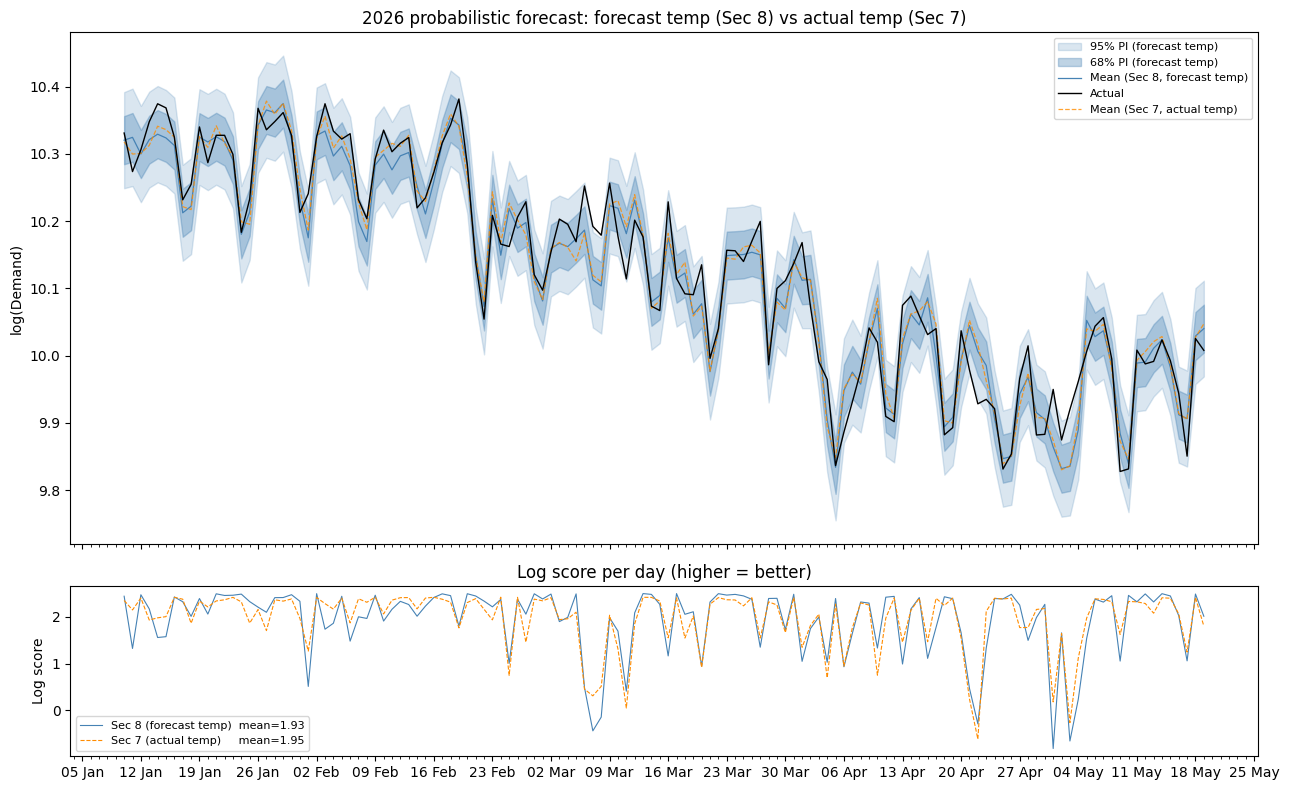

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.fill_between(mus8_test.index, mus8_test - 2*sigmas8_test, mus8_test + 2*sigmas8_test,
                alpha=0.20, color="steelblue", label="95% PI (forecast temp)")
ax.fill_between(mus8_test.index, mus8_test - sigmas8_test,   mus8_test + sigmas8_test,
                alpha=0.35, color="steelblue", label="68% PI (forecast temp)")
ax.plot(mus8_test.index,       mus8_test.values,       lw=0.9, color="steelblue",  label="Mean (Sec 8, forecast temp)")
ax.plot(y_act8.index,    y_act8.values,    lw=1.0, color="black",       label="Actual", zorder=4)
ax.plot(mu7_same.index,  mu7_same.values,  lw=0.9, color="darkorange", linestyle="--", alpha=0.8, label="Mean (Sec 7, actual temp)")
ax.set_ylabel("log(Demand)")
ax.set_title("2026 probabilistic forecast: forecast temp (Sec 8) vs actual temp (Sec 7)")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_minor_locator(mdates.DayLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

axes[1].plot(log_scores8.index, log_scores8.values, lw=0.8, color="steelblue",  label=f"Sec 8 (forecast temp)  mean={log_scores8.mean():.2f}")
axes[1].plot(ls7_same.index,    ls7_same.values,    lw=0.8, color="darkorange", linestyle="--", label=f"Sec 7 (actual temp)     mean={ls7_same.mean():.2f}")
axes[1].set_ylabel("Log score")
axes[1].set_title("Log score per day (higher = better)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Two-Step Ahead Forecast: 4 May and 5 May 2026

We have observed demand through **3 May 2026**.
The forecast horizon rows (May 4, May 5) were added to `df` in Section 2.5,
so the feature matrix already contains the correct HDD, CDD, diurnal spread,
sunshine, and calendar features for those dates -- derived from the competition's
weather model forecasts.

The model is trained once on all clean rows (demand observed, no NaN features).

In [31]:
def compute_adaptive_multiplier(past_df, m_fixed, window=30, min_obs=14):
    """
    Scales m_fixed up or down based on whether recent full-stack residuals
    were larger or smaller than m_fixed * sigma_base predicted.
    """
    if len(past_df) < min_obs:
        return m_fixed

    recent       = past_df.iloc[-window:]
    actual_resid = recent["log_demand"] - recent["mu_pred"]
    realised_vol = actual_resid.std()
    expected_vol = (m_fixed * recent["sigma_base"]).mean()
    correction   = realised_vol / expected_vol

    dampening  = 0.5  # prevents overreaction to a single unusual window
    m_adaptive = m_fixed * (1 + dampening * (correction - 1))

    return float(np.clip(m_adaptive, 0.5 * m_fixed, 2.0 * m_fixed))


# Build track record from test-set predictions (mus8_test / sigmas8_test)
# These cover the most recent observed period — the right basis for adaption
_last_obs = df['log_demand'].dropna().index.max()
past_df = pd.DataFrame({
    "mu_pred":    mus8_test,
    "sigma_base": sigmas8_test,
    "log_demand": features["log_demand"],
}).dropna().loc[:_last_obs]

adaptive_m = compute_adaptive_multiplier(past_df, best_m_conservative, window=30)
print(f'Conservative m  : {best_m_conservative:.3f}  (Section 8 validation)')
print(f'Adaptive m      : {adaptive_m:.3f}  (last 30 days of test-period track record)')

Conservative m  : 0.924  (Section 8 validation)
Adaptive m      : 1.059  (last 30 days of test-period track record)


In [32]:
# === DEMAND DATA DIAGNOSTIC ===

# Dates
last_date = df['log_demand'].dropna().index.max() - pd.Timedelta(days=0)
today    = last_date + pd.Timedelta(days=1)
tomorrow = last_date + pd.Timedelta(days=2)

print(f'Last observed demand : {last_date.date()}')
print(f'Forecast day 1       : {today.date()}  ({today.strftime("%A")})')
print(f'Forecast day 2       : {tomorrow.date()}  ({tomorrow.strftime("%A")})')

# Train OLS on all clean rows (NaN-demand forecast rows excluded by dropna)
all_clean = features.dropna()
X_all     = np.column_stack([np.ones(len(all_clean)), all_clean[FEATURE_COLS].values])
y_all     = all_clean['log_demand'].values
n_all, p_all = len(y_all), len(FEATURE_COLS)

XtX_inv = np.linalg.inv(X_all.T @ X_all)
beta    = XtX_inv @ (X_all.T @ y_all)
mse     = np.dot(y_all - X_all @ beta, y_all - X_all @ beta) / (n_all - p_all - 1)
print(f'\nOLS trained on {n_all} obs ({all_clean.index.min().date()} to {all_clean.index.max().date()})')

# XGBoost on OLS residuals (3-year sliding window)
resid_all = y_all - X_all @ beta
xgb_mask  = all_clean.index >= last_date - pd.Timedelta(days=1095)
xgb_final = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb_final.fit(all_clean[FEATURE_COLS].values[xgb_mask], resid_all[xgb_mask])

# AR(2,7) on XGB-corrected residuals (last 90 days)
_ar_mask  = all_clean.index >= last_date - pd.Timedelta(days=90)
_ar_vals = resid_all[_ar_mask] - xgb_final.predict(all_clean[FEATURE_COLS].values[_ar_mask])
ar_model_final = AutoReg(_ar_vals, lags=[2, 7], old_names=False).fit()
print(f'Sigma calibration    : adaptive_m = {adaptive_m:.3f}  conservative_m = {best_m_conservative:.3f}')


def ols_predict(feat_row, multiplier=None, h=1, debug=False):
    if multiplier is None:
        multiplier = adaptive_m
    x_arr    = feat_row.values.astype(float)
    x        = np.r_[1.0, x_arr]
    mu_ols   = x @ beta
    xgb_corr = xgb_final.predict(x_arr.reshape(1, -1))[0]
    ar_corr  = float(np.asarray(ar_model_final.forecast(h))[-1])
    mu       = mu_ols + xgb_corr + ar_corr
    sigma    = np.sqrt(mse * (1.0 + x @ XtX_inv @ x)) * multiplier
    if debug:
        print(f'    OLS only       : {np.exp(mu_ols):>10,.0f} MWh  (log={mu_ols:.4f})')
        print(f'    + XGB corr     : {np.exp(mu_ols+xgb_corr):>10,.0f} MWh  (delta={xgb_corr:+.4f})')
        print(f'    + AR  corr     : {np.exp(mu):>10,.0f} MWh  (delta={ar_corr:+.4f})(log={mu})')
    return mu, sigma


def show(label, date, mu, sigma, feat_row, h):
    lo95 = np.exp(mu - 1.96 * sigma)
    hi95 = np.exp(mu + 1.96 * sigma)
    print(f'  {label} -- {date.strftime("%A %d %B %Y")}')
    ols_predict(feat_row, h=h, debug=True)
    print(f'    Point estimate : {np.exp(mu):>10,.0f} MWh')
    print(f'    95% PI         : [{lo95:>9,.0f}  -  {hi95:>9,.0f}] MWh')
    # Key features for sanity-check
    idx = list(FEATURE_COLS)
    def f(col): return feat_row[col] if col in idx else float('nan')
    print(f'    [features]  HDD_london={f("HDD_london"):.2f}  sun_london_h={f("sun_london_h"):.2f}  '
          f'low_HDD={f("low_HDD_regime"):.0f}  lag_2={f("lag_2"):.4f}  roll7={f("roll7_mean"):.4f}')
    dow_cols = [c for c in idx if c.startswith("dow_")]
    active_dow = [c.replace("dow_","") for c in dow_cols if feat_row[c] == 1]
    print(f'    [calendar]  day={active_dow}  month_May={f("month_May"):.0f}  '
          f'school_hol={f("is_school_holiday"):.0f}  holiday={f("is_holiday_generic_bh"):.0f}')


feat4     = features.loc[today,    FEATURE_COLS]
mu4, sig4 = ols_predict(feat4, h=1)

feat5     = features.loc[tomorrow, FEATURE_COLS]
mu5, sig5 = ols_predict(feat5, h=2)

print()
print('=' * 62)
print('  FORECASTS  (OLS + XGB + AR correction, adaptive sigma)')
print('=' * 62)
show('Day 1', today,    mu4, sig4, feat4, h=1)
print()
show('Day 2', tomorrow, mu5, sig5, feat5, h=2)
print('=' * 62)

Last observed demand : 2026-05-19
Forecast day 1       : 2026-05-20  (Wednesday)
Forecast day 2       : 2026-05-21  (Thursday)

OLS trained on 1960 obs (2021-01-06 to 2026-05-19)
Sigma calibration    : adaptive_m = 1.059  conservative_m = 0.924

  FORECASTS  (OLS + XGB + AR correction, adaptive sigma)
  Day 1 -- Wednesday 20 May 2026
    OLS only       :     22,215 MWh  (log=10.0085)
    + XGB corr     :     22,810 MWh  (delta=+0.0264)
    + AR  corr     :     22,873 MWh  (delta=+0.0027)(log=10.0377059742664)
    Point estimate :     22,873 MWh
    95% PI         : [   21,245  -     24,626] MWh
    [features]  HDD_london=0.00  sun_london_h=3.00  low_HDD=1  lag_2=10.0255  roll7=9.9736
    [calendar]  day=['Wed']  month_May=1  school_hol=0  holiday=0

  Day 2 -- Thursday 21 May 2026
    OLS only       :     21,498 MWh  (log=9.9757)
    + XGB corr     :     22,017 MWh  (delta=+0.0239)
    + AR  corr     :     22,094 MWh  (delta=+0.0035)(log=10.00307383941537)
    Point estimate :     22,0

In [33]:
# === DEMAND DATA DIAGNOSTIC ===
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from statsmodels.tsa.ar_model import AutoReg

# Dates
# Change days=1 or days=0 here to backtest. The code is now safe from data leakage.
last_date = df['log_demand'].dropna().index.max() - pd.Timedelta(days=2)
today    = last_date + pd.Timedelta(days=1)
tomorrow = last_date + pd.Timedelta(days=2)

print(f'Last observed demand : {last_date.date()}')
print(f'Forecast day 1       : {today.date()}  ({today.strftime("%A")})')
print(f'Forecast day 2       : {tomorrow.date()}  ({tomorrow.strftime("%A")})')


XGB_FEATURE_COLS = [col for col in FEATURE_COLS if col != 'year_trend']

#print(XGB_FEATURE_COLS)

# Train OLS on all clean rows (NaN-demand forecast rows excluded by dropna)
# FIXED: Capped data at last_date to prevent data leakage during backtesting
all_clean = features.dropna().loc[:last_date] 
X_all     = np.column_stack([np.ones(len(all_clean)), all_clean[FEATURE_COLS].values])
y_all     = all_clean['log_demand'].values
n_all, p_all = len(y_all), len(FEATURE_COLS)

XtX_inv = np.linalg.inv(X_all.T @ X_all)
beta    = XtX_inv @ (X_all.T @ y_all)
mse     = np.dot(y_all - X_all @ beta, y_all - X_all @ beta) / (n_all - p_all - 1)
print(f'\nOLS trained on {n_all} obs ({all_clean.index.min().date()} to {all_clean.index.max().date()})')

# XGBoost on OLS residuals (3-year sliding window)
resid_all = y_all - X_all @ beta
xgb_mask  = all_clean.index >= last_date - pd.Timedelta(days=1095)
xgb_final = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb_final.fit(all_clean[XGB_FEATURE_COLS].values[xgb_mask], resid_all[xgb_mask])

# AR(2,7) on XGB-corrected residuals (last 90 days)
_ar_mask  = all_clean.index >= last_date - pd.Timedelta(days=90)
_ar_vals = resid_all[_ar_mask] - xgb_final.predict(all_clean[XGB_FEATURE_COLS].values[_ar_mask])
ar_model_final = AutoReg(_ar_vals, lags=[2, 7], old_names=False).fit()

# Assuming adaptive_m and best_m_conservative are defined earlier in your notebook
print(f'Sigma calibration    : adaptive_m = {adaptive_m:.3f}  conservative_m = {best_m_conservative:.3f}')


def ols_predict(feat_row, multiplier=None, h=1, debug=False):
    if multiplier is None:
        multiplier = adaptive_m
    x_arr    = feat_row.values.astype(float)
    x        = np.r_[1.0, x_arr]
    mu_ols   = x @ beta
    xgb_corr = xgb_final.predict(x_arr.reshape(1, -1))[0]
    ar_corr  = float(np.asarray(ar_model_final.forecast(h))[-1])
    mu       = mu_ols + xgb_corr + ar_corr
    sigma    = np.sqrt(mse * (1.0 + x @ XtX_inv @ x)) * multiplier
    if debug:
        print(f'    OLS only       : {np.exp(mu_ols):>10,.0f} MWh  (log={mu_ols:.4f})')
        print(f'    + XGB corr     : {np.exp(mu_ols+xgb_corr):>10,.0f} MWh  (delta={xgb_corr:+.4f})')
        print(f'    + AR  corr     : {np.exp(mu):>10,.0f} MWh  (delta={ar_corr:+.4f})(log={mu})')
    return mu, sigma

def ols_predict(feat_row, multiplier=None, h=1, debug=False):
    if multiplier is None:
        multiplier = adaptive_m
        
    # 1. OLS gets all features (including year_trend)
    x_ols_arr = feat_row[FEATURE_COLS].values.astype(float)
    x         = np.r_[1.0, x_ols_arr]
    mu_ols    = x @ beta
    
    # 2. XGBoost gets the restricted features (NO year_trend)
    x_xgb_arr = feat_row[XGB_FEATURE_COLS].values.astype(float)
    xgb_corr  = xgb_final.predict(x_xgb_arr.reshape(1, -1))[0]
    
    # 3. AR gets the h-step forecast
    ar_corr   = float(np.asarray(ar_model_final.forecast(h))[-1])
    
    mu        = mu_ols + xgb_corr + ar_corr
    sigma     = np.sqrt(mse * (1.0 + x @ XtX_inv @ x)) * multiplier
    
    if debug:
        print(f'    OLS only       : {np.exp(mu_ols):>10,.0f} MWh  (log={mu_ols:.4f})')
        print(f'    + XGB corr     : {np.exp(mu_ols+xgb_corr):>10,.0f} MWh  (delta={xgb_corr:+.4f})')
        print(f'    + AR  corr     : {np.exp(mu):>10,.0f} MWh  (delta={ar_corr:+.4f})(log={mu})')
    
    return mu, sigma


def show(label, date, mu, sigma, feat_row, h):
    lo95 = np.exp(mu - 1.96 * sigma)
    hi95 = np.exp(mu + 1.96 * sigma)
    print(f'  {label} -- {date.strftime("%A %d %B %Y")}')
    ols_predict(feat_row, h=h, debug=True)
    print(f'    Point estimate : {np.exp(mu):>10,.0f} MWh')
    print(f'    95% PI         : [{lo95:>9,.0f}  -  {hi95:>9,.0f}] MWh')
    # Key features for sanity-check
    idx = list(FEATURE_COLS)
    def f(col): return feat_row[col] if col in idx else float('nan')
    print(f'    [features]  HDD_london={f("HDD_london"):.2f}  sun_london_h={f("sun_london_h"):.2f}  '
          f'low_HDD={f("low_HDD_regime"):.0f}  lag_2={f("lag_2"):.4f}  roll7={f("roll7_mean"):.4f}')
    dow_cols = [c for c in idx if c.startswith("dow_")]
    active_dow = [c.replace("dow_","") for c in dow_cols if feat_row[c] == 1]
    print(f'    [calendar]  day={active_dow}  month_May={f("month_May"):.0f}  '
          f'school_hol={f("is_school_holiday"):.0f}  holiday={f("is_holiday_generic_bh"):.0f}')


feat4     = features.loc[today,    FEATURE_COLS]
mu4, sig4 = ols_predict(feat4, multiplier=best_m_conservative, h=1)

feat5     = features.loc[tomorrow, FEATURE_COLS]
mu5, sig5 = ols_predict(feat5, multiplier=best_m_conservative, h=2)

print()
print('=' * 62)
print('  FORECASTS  (OLS + XGB + AR correction, adaptive sigma)')
print('=' * 62)
show('Day 1', today,    mu4, sig4, feat4, h=1)
print()
show('Day 2', tomorrow, mu5, sig5, feat5, h=2)
print('=' * 62)

Last observed demand : 2026-05-17
Forecast day 1       : 2026-05-18  (Monday)
Forecast day 2       : 2026-05-19  (Tuesday)

OLS trained on 1958 obs (2021-01-06 to 2026-05-17)
Sigma calibration    : adaptive_m = 1.059  conservative_m = 0.924

  FORECASTS  (OLS + XGB + AR correction, adaptive sigma)
  Day 1 -- Monday 18 May 2026
    OLS only       :     22,755 MWh  (log=10.0325)
    + XGB corr     :     22,600 MWh  (delta=-0.0068)
    + AR  corr     :     22,697 MWh  (delta=+0.0043)(log=10.029966045179268)
    Point estimate :     22,697 MWh
    95% PI         : [   21,279  -     24,209] MWh
    [features]  HDD_london=3.90  sun_london_h=6.20  low_HDD=1  lag_2=9.9441  roll7=9.9685
    [calendar]  day=[]  month_May=1  school_hol=0  holiday=0

  Day 2 -- Tuesday 19 May 2026
    OLS only       :     22,403 MWh  (log=10.0169)
    + XGB corr     :     22,638 MWh  (delta=+0.0105)
    + AR  corr     :     22,950 MWh  (delta=+0.0137)(log=10.041054950037742)
    Point estimate :     22,950 MWh
   

In [34]:
# Make sure to pip install shap if you haven't already
import shap
import pandas as pd

# 1. Initialize the explainer with your trained XGBoost model
explainer = shap.Explainer(xgb_final)

# 2. Grab the exact features for your most recent prediction (Day 2 / tomorrow)
# We reshape it because SHAP expects a 2D array, just like model.predict()
X_recent = feat5[XGB_FEATURE_COLS].values.astype(float).reshape(1, -1)

# 3. Calculate SHAP values for this specific day
shap_values = explainer(X_recent)

# 4. Create a clean, sorted table to see exactly what drove the correction
shap_df = pd.DataFrame({
    'Feature': XGB_FEATURE_COLS,
    'Feature_Value': X_recent[0],           # The actual value of the feature that day
    'Impact_on_Prediction': shap_values.values[0] # How much MWh it added or subtracted
})

# Sort by absolute impact to put the biggest drivers at the top
shap_df['Absolute_Impact'] = shap_df['Impact_on_Prediction'].abs()
shap_df = shap_df.sort_values(by='Absolute_Impact', ascending=False).drop(columns='Absolute_Impact')

print("\n" + "="*62)
print("  XGBOOST FEATURE BREAKDOWN (MOST RECENT PREDICTION)")
print("="*62)
print(shap_df.head(10).to_string(index=False)) # Showing the top 10 biggest drivers

# OPTIONAL: If you are using a Jupyter Notebook, uncomment the line below 
# to generate a visual waterfall chart of these exact numbers.
# shap.waterfall_plot(shap_values[0])


  XGBOOST FEATURE BREAKDOWN (MOST RECENT PREDICTION)
            Feature  Feature_Value  Impact_on_Prediction
      lag_365_roll7         9.8829               -0.0046
              lag_2         9.8506                0.0045
temp_bristol_spread         4.3450                0.0030
      sun_bristol_h         1.7677                0.0026
        sun_leeds_h         0.4646                0.0021
       temp_anomaly        -0.4751               -0.0019
              lag_7         9.9877                0.0017
         roll7_mean         9.9712                0.0016
sun_leeds_x_low_HDD         0.4646                0.0015
          HDD_leeds         2.7203               -0.0012


/opt/miniconda3/envs/deep_l_tensor/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# ── Final submission values ─────────────────────────────────────────────────
print(f'Day 1  {today.strftime("%A %d %b %Y")}  mu = {mu4:.6f}   sigma = {sig4:.6f}   point = {np.exp(mu4):,.0f} MWh')
print(f'Day 2  {tomorrow.strftime("%A %d %b %Y")}  mu = {mu5:.6f}   sigma = {sig5:.6f}   point = {np.exp(mu5):,.0f} MWh')


Day 1  Monday 18 May 2026  mu = 10.029966   sigma = 0.032907   point = 22,697 MWh
Day 2  Tuesday 19 May 2026  mu = 10.041055   sigma = 0.032884   point = 22,950 MWh
